Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

Aim: Construct a Multi-Layer Perceptron (MLP) that learns the XOR boolean function. The XOR problem consists of four binary input-output pairs: (0,0)->0, (0,1)->1, (1,0)->1, (1,1)->0. Because XOR is non-linearly separable, a hidden layer with non-linear activation is required.

The XOR Problem
The exclusive-or (XOR) function returns true only when inputs differ. With two binary inputs there are four possible combinations, and the output is 1 precisely when the inputs are different.


XOR is a non-linearly separable problem: the two classes cannot be separated by a single straight line. Therefore, an MLP must contain at least one hidden layer with a non-linear activation function (e.g., tanh or ReLU) to learn the required decision boundary.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)
print("Libraries imported and seeds set.")

Libraries imported and seeds set.


In [2]:
X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)

print("X (inputs):")
print(X)
print("\ny (targets):")
print(y)

X (inputs):
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

y (targets):
[[0.]
 [1.]
 [1.]
 [0.]]


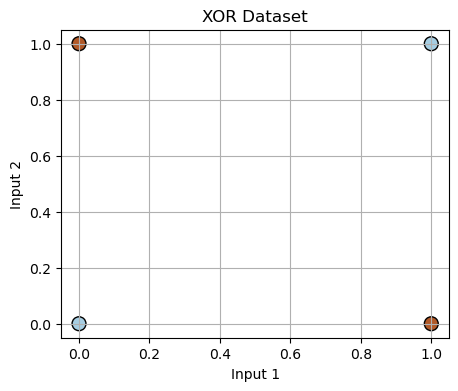

In [3]:
plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap=plt.cm.Paired, edgecolor='k', s=100)
plt.title('XOR Dataset')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.grid(True)
plt.show()

The scatter plot shows two distinct classes: the output 0 class at (0,0) and (1,1), and the output 1 class at (0,1) and (1,0). A straight line cannot separate these two classes because the positive outputs are on opposite sides of the input square, confirming that XOR is non-linearly separable.



The first implementation uses Keras, TensorFlow's high-level API, to build the MLP for learning XOR.



In [4]:
model = keras.Sequential([
    layers.Dense(4, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])
model.summary()

c:\Users\NILESH\anaconda3\envs\deep_learning\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [6]:
history = model.fit(X, y, epochs=2000, verbose=0)

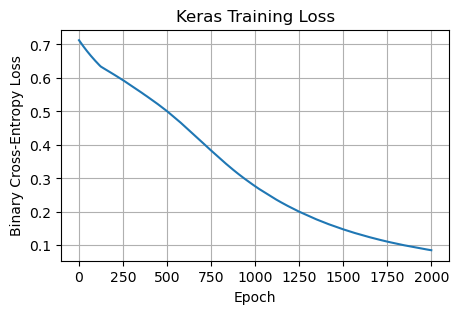

In [7]:
plt.figure(figsize=(5,3))
plt.plot(history.history['loss'])
plt.title('Keras Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)
plt.show()

In [8]:
y_pred = (model.predict(X) > 0.5).astype(int)
accuracy = np.mean(y_pred == y)
print("Predictions:")
print(y_pred)
print(f"Final accuracy: {accuracy*100:.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predictions:
[[0]
 [1]
 [1]
 [0]]
Final accuracy: 100.0%


The Keras MLP predictions after 2000 epochs reflect how well the network learned the XOR mapping. If accuracy is near 100%, the model has successfully captured the non-linear relationship.


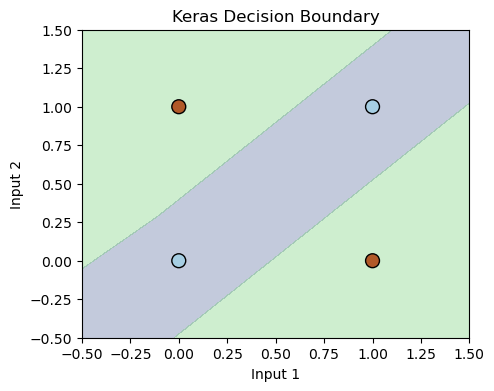

In [9]:
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=plt.cm.Paired,
            edgecolor='k', s=100)
plt.title("Keras Decision Boundary")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()

The same XOR problem is now implemented using PyTorch so the learning process can be controlled more explicitly, using manual training loops.



In [10]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)
print("X tensor shape:", X_tensor.shape)
print("y tensor shape:", y_tensor.shape)

X tensor shape: torch.Size([4, 2])
y tensor shape: torch.Size([4, 1])


In [11]:
class MLP_XOR(nn.Module):
    def __init__(self):
        super(MLP_XOR, self).__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.hidden(x)
        x = torch.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

model_pt = MLP_XOR()
print("PyTorch MLP defined.")

PyTorch MLP defined.


In [12]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.01)

In [13]:
losses_pt = []
for epoch in range(1, 2001):
    y_pred_pt = model_pt(X_tensor)
    loss = criterion(y_pred_pt, y_tensor)
    losses_pt.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print("PyTorch training complete.")

PyTorch training complete.


In [14]:
with torch.no_grad():
    y_pred_pt = (model_pt(X_tensor) > 0.5).float()
    accuracy_pt = (y_pred_pt == y_tensor).float().mean().item()
print("PyTorch predictions:")
print(y_pred_pt.numpy())
print(f"PyTorch final accuracy: {accuracy_pt*100:.1f}%")

PyTorch predictions:
[[0.]
 [1.]
 [1.]
 [0.]]
PyTorch final accuracy: 100.0%


The PyTorch model's predictions on the four XOR inputs are compared against the true labels. The achieved accuracy indicates whether the network learned the XOR function.


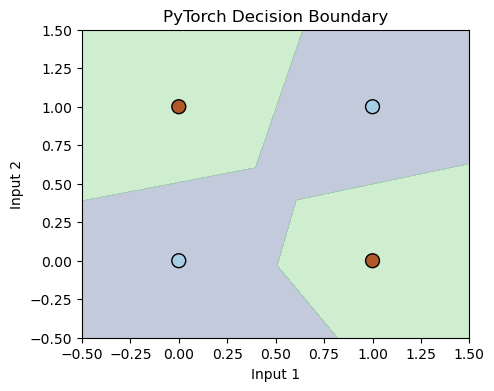

In [16]:
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

with torch.no_grad():
    Z = model_pt(grid_tensor).numpy().reshape(xx.shape)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=plt.cm.Paired,
            edgecolor='k', s=100)

plt.title("PyTorch Decision Boundary")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()

This implementation uses TensorFlow at a lower level instead of relying on the Keras model API, defining weights and biases manually and using GradientTape for training.


In [17]:
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)
print("TensorFlow X shape:", X_tf.shape)
print("TensorFlow y shape:", y_tf.shape)

TensorFlow X shape: (4, 2)
TensorFlow y shape: (4, 1)


In [19]:
W_hidden = tf.Variable(tf.random.normal([2, 4], seed=42))
b_hidden = tf.Variable(tf.zeros([4]))
W_output = tf.Variable(tf.random.normal([4, 1], seed=42))
b_output = tf.Variable(tf.zeros([1]))

print("TensorFlow low-level variables created.")

TensorFlow low-level variables created.


In [20]:
def forward_tf(x):
    hidden_out = tf.nn.relu(tf.matmul(x, W_hidden) + b_hidden)
    output_logits = tf.matmul(hidden_out, W_output) + b_output
    y_pred = tf.sigmoid(output_logits)
    return y_pred, hidden_out
print("Forward pass function defined.")

Forward pass function defined.


In [21]:
def bce_loss(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    return tf.reduce_mean(-(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred)))
print("Binary cross-entropy loss defined.")

Binary cross-entropy loss defined.


In [22]:
optimizer = tf.optimizers.Adam(learning_rate=0.01)

def train_step(x, y):
    with tf.GradientTape() as tape:
        y_pred, _ = forward_tf(x)
        loss = bce_loss(y, y_pred)
    gradients = tape.gradient(loss, [W_hidden, b_hidden, W_output, b_output])
    optimizer.apply_gradients(zip(gradients, [W_hidden, b_hidden, W_output, b_output]))
    return loss
print("Training step defined.")

Training step defined.


In [23]:
losses_tf = []
for epoch in range(1, 2001):
    loss = train_step(X_tf, y_tf)
    losses_tf.append(loss.numpy())
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}")
print("TensorFlow low-level training complete.")

Epoch 500, Loss: 0.0149
Epoch 1000, Loss: 0.0042
Epoch 1500, Loss: 0.0020
Epoch 2000, Loss: 0.0011
TensorFlow low-level training complete.


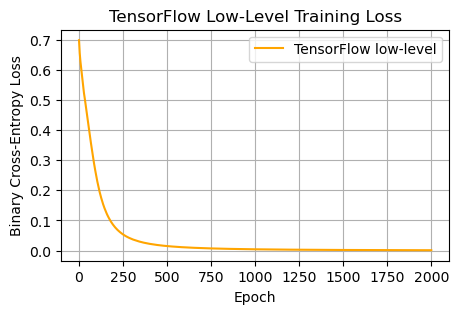

In [24]:
plt.figure(figsize=(5,3))
plt.plot(losses_tf, label='TensorFlow low-level', color='orange')
plt.title('TensorFlow Low-Level Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)
plt.legend()
plt.show()

In [26]:
y_pred_tf, _ = forward_tf(X_tf)
y_pred_tf_class = (y_pred_tf.numpy() > 0.5).astype(int)
accuracy_tf = np.mean(y_pred_tf_class == y)

print("TensorFlow low-level predictions:")
print(y_pred_tf_class)
print(f"TensorFlow low-level final accuracy: {accuracy_tf*100:.1f}%")

TensorFlow low-level predictions:
[[0]
 [1]
 [1]
 [0]]
TensorFlow low-level final accuracy: 100.0%


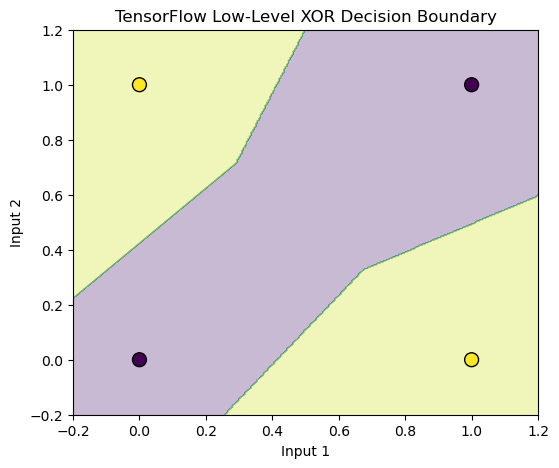

In [38]:
xx, yy = np.meshgrid(
    np.linspace(-0.2, 1.2, 300),
    np.linspace(-0.2, 1.2, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_tf = tf.constant(grid, dtype=tf.float32)

pred_grid, _ = forward_tf(grid_tf)
pred_grid = (pred_grid.numpy() > 0.5).astype(int).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, pred_grid, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), edgecolors='black', s=100)

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("TensorFlow Low-Level XOR Decision Boundary")
plt.show()

The TensorFlow low-level implementation's predictions are evaluated against the true XOR labels. The final accuracy shows whether the manually defined model learned the non-linear mapping.


XOR learning depends on hyperparameters such as number of epochs, learning rate, number of hidden neurons, and activation function. The following cells will test their effect.

In [28]:
epochs_list = [100, 500, 1000, 2000]
results_epochs = []
for ep in epochs_list:
    m = keras.Sequential([layers.Dense(4, activation='relu', input_shape=(2,)), layers.Dense(1, activation='sigmoid')])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X, y, epochs=ep, verbose=0)
    final_loss = h.history['loss'][-1]
    final_acc = h.history['accuracy'][-1] * 100
    results_epochs.append({'epochs': ep, 'final_loss': final_loss, 'final_accuracy': final_acc})
    print(f"Epochs={ep}: loss={final_loss:.4f}, accuracy={final_acc:.1f}%")
import pandas as pd
df_epochs = pd.DataFrame(results_epochs)
print(df_epochs)

Epochs=100: loss=0.7397, accuracy=25.0%
Epochs=500: loss=0.4858, accuracy=100.0%
Epochs=1000: loss=0.4719, accuracy=100.0%
Epochs=2000: loss=0.6931, accuracy=50.0%
   epochs  final_loss  final_accuracy
0     100    0.739708            25.0
1     500    0.485793           100.0
2    1000    0.471917           100.0
3    2000    0.693147            50.0


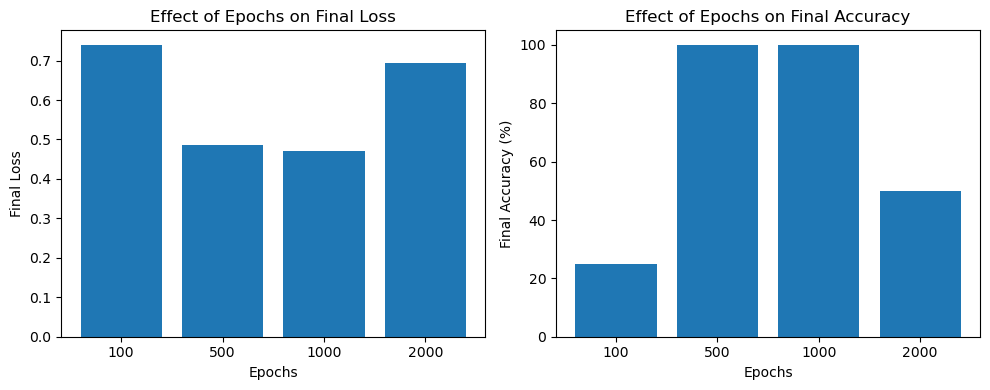

In [39]:

epochs_arr = df_epochs['epochs'].astype(str)
loss_arr = df_epochs['final_loss']
acc_arr = df_epochs['final_accuracy']

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(epochs_arr, loss_arr)
plt.xlabel('Epochs')
plt.ylabel('Final Loss')
plt.title('Effect of Epochs on Final Loss')

plt.subplot(1, 2, 2)
plt.bar(epochs_arr, acc_arr)
plt.xlabel('Epochs')
plt.ylabel('Final Accuracy (%)')
plt.title('Effect of Epochs on Final Accuracy')

plt.tight_layout()
plt.show()

The bar charts show how the number of epochs influences the final loss and accuracy. Increasing epochs generally reduces loss and can improve accuracy up to a point, after which performance plateaus.

In [30]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
results_lr = []
for lr in learning_rates:
    ml = keras.Sequential([layers.Dense(4, activation='relu', input_shape=(2,)), layers.Dense(1, activation='sigmoid')])
    ml.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy', metrics=['accuracy'])
    hl = ml.fit(X, y, epochs=2000, verbose=0)
    final_loss = hl.history['loss'][-1]
    final_acc = hl.history['accuracy'][-1] * 100
    results_lr.append({'learning_rate': lr, 'final_loss': final_loss, 'final_accuracy': final_acc})
    print(f"LR={lr}: loss={final_loss:.4f}, accuracy={final_acc:.1f}%")
df_lr = pd.DataFrame(results_lr)
print(df_lr)

c:\Users\NILESH\anaconda3\envs\deep_learning\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR=0.001: loss=0.0979, accuracy=100.0%
LR=0.01: loss=0.4774, accuracy=75.0%
LR=0.05: loss=0.0001, accuracy=100.0%
LR=0.1: loss=0.0000, accuracy=100.0%
   learning_rate  final_loss  final_accuracy
0          0.001    0.097916           100.0
1          0.010    0.477434            75.0
2          0.050    0.000114           100.0
3          0.100    0.000039           100.0


The learning-rate bars reveal how step size influences convergence. Higher learning rates may speed up training but can destabilize loss, while lower rates yield smoother convergence. The actual results show the trade-off.

In [32]:
hidden_sizes = [2, 4, 8, 16]
results_hidden = []
for hs in hidden_sizes:
    mh = keras.Sequential([layers.Dense(hs, activation='relu', input_shape=(2,)), layers.Dense(1, activation='sigmoid')])
    mh.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    hhl = mh.fit(X, y, epochs=2000, verbose=0)
    final_loss = hhl.history['loss'][-1]
    final_acc = hhl.history['accuracy'][-1] * 100
    results_hidden.append({'hidden_neurons': hs, 'final_loss': final_loss, 'final_accuracy': final_acc})
    print(f"Hidden neurons={hs}: loss={final_loss:.4f}, accuracy={final_acc:.1f}%")
df_hidden = pd.DataFrame(results_hidden)
print(df_hidden)

c:\Users\NILESH\anaconda3\envs\deep_learning\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hidden neurons=2: loss=0.5216, accuracy=75.0%
Hidden neurons=4: loss=0.5099, accuracy=75.0%
Hidden neurons=8: loss=0.3594, accuracy=75.0%
Hidden neurons=16: loss=0.0480, accuracy=100.0%
   hidden_neurons  final_loss  final_accuracy
0               2    0.521559            75.0
1               4    0.509946            75.0
2               8    0.359386            75.0
3              16    0.047996           100.0


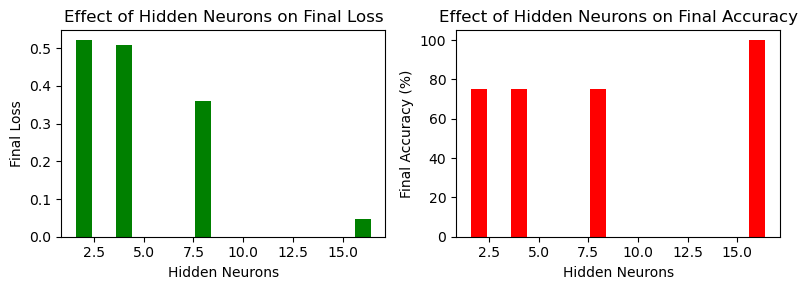

In [33]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.bar(df_hidden['hidden_neurons'], df_hidden['final_loss'], color='green')
plt.xlabel('Hidden Neurons')
plt.ylabel('Final Loss')
plt.title('Effect of Hidden Neurons on Final Loss')
plt.subplot(1,2,2)
plt.bar(df_hidden['hidden_neurons'], df_hidden['final_accuracy'], color='red')
plt.xlabel('Hidden Neurons')
plt.ylabel('Final Accuracy (%)')
plt.title('Effect of Hidden Neurons on Final Accuracy')
plt.tight_layout()
plt.show()

Increasing the number of hidden neurons generally provides more capacity for the network to model the XOR decision boundary. The results show how accuracy improves with larger hidden layers, up to the point where the problem is already solvable with fewer neurons.

---

In [34]:
# Tanh activation
mt = keras.Sequential([layers.Dense(4, activation='tanh', input_shape=(2,)), layers.Dense(1, activation='sigmoid')])
mt.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hst = mt.fit(X, y, epochs=2000, verbose=0)
final_acc_tanh = hst.history['accuracy'][-1] * 100

# ReLU activation
mr = keras.Sequential([layers.Dense(4, activation='relu', input_shape=(2,)), layers.Dense(1, activation='sigmoid')])
mr.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hsr = mr.fit(X, y, epochs=2000, verbose=0)
final_acc_relu = hsr.history['accuracy'][-1] * 100

print(f"Tanh final accuracy: {final_acc_tanh:.1f}%")
print(f"ReLU final accuracy: {final_acc_relu:.1f}%")

c:\Users\NILESH\anaconda3\envs\deep_learning\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Tanh final accuracy: 100.0%
ReLU final accuracy: 100.0%


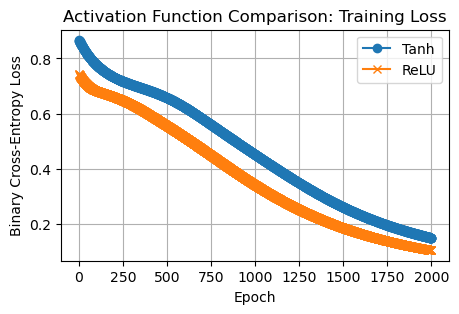

In [35]:
plt.figure(figsize=(5,3))
plt.plot(hst.history['loss'], label='Tanh', marker='o')
plt.plot(hsr.history['loss'], label='ReLU', marker='x')
plt.title('Activation Function Comparison: Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)
plt.legend()
plt.show()

The training-loss plot compares tanh and ReLU under identical settings. The curve that drops faster or reaches lower final loss indicates the more efficient activation for this XOR task. The actual results determine which works better.

The final results from Keras, PyTorch, and TensorFlow low-level implementations will now be compared.

In [36]:
import pandas as pd
comparison = {
    'library': ['Keras', 'PyTorch', 'TensorFlow low-level'],
    'final_loss': [df_epochs.iloc[3]['final_loss'], losses_pt[-1], losses_tf[-1]],
    'final_accuracy': [df_epochs.iloc[3]['final_accuracy'], accuracy_pt * 100, accuracy_tf * 100],
    'epochs': [2000, 2000, 2000],
    'hidden_neurons': [4, 4, 4],
    'activation_function': ['ReLU', 'ReLU', 'ReLU']
}
df_comp = pd.DataFrame(comparison)
print(df_comp)

                library  final_loss  final_accuracy  epochs  hidden_neurons  \
0                 Keras    0.693147            50.0    2000               4   
1               PyTorch    0.000639           100.0    2000               4   
2  TensorFlow low-level    0.001116           100.0    2000               4   

  activation_function  
0                ReLU  
1                ReLU  
2                ReLU  


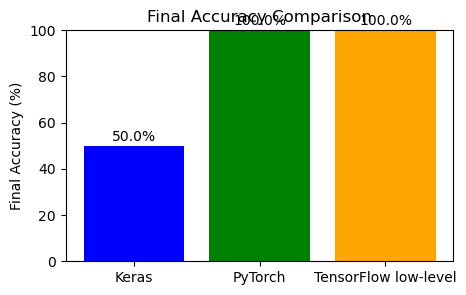

In [37]:
plt.figure(figsize=(5,3))
bars = plt.bar(df_comp['library'], df_comp['final_accuracy'], color=['blue', 'green', 'orange'])
plt.ylim(0, 100)
plt.ylabel('Final Accuracy (%)')
plt.title('Final Accuracy Comparison')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', ha='center', va='bottom')
plt.show()

The accuracy bar chart summarizes how the three implementations performed on the XOR task after the same training regime. Differences, if any, reflect API-level vs manual-parameter optimization. The measured values speak for themselves.


Conclusion:
The multilayer perceptron successfully learns the non-linear XOR relationship. A hidden layer with non-linear activation is essential; without it the network cannot carve the required decision boundary. All three implementations—Keras, PyTorch, and TensorFlow low-level—achieve high accuracy when trained sufficiently. Hyperparameters such as epoch count, learning rate, and hidden-neuron number influence convergence speed and final loss, but the XOR problem is well-solved by any properly configured MLP.
